# Лабораторная работа 12. Отравление данных и атаки на приватность


**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 9**

Курс «Глубокое обучение и безопасность нейронных сетей». Уровень: бакалавриат, Python и основы PyTorch.

**Вариант / seed:** _номер варианта или значение SEED_

Все эксперименты выполняются на собственных локальных моделях, открытых цифрах 8×8 и синтетических векторах.
Нет внешних API, персональных данных, ключей или скачивания весов.

## План

| Блок | Эксперимент | Главный вопрос |
|---|---|---|
| A | Baseline и label flipping | Что меняется при повреждении меток? |
| B | Backdoor и контроль известного триггера | Может ли высокая clean accuracy скрывать уязвимость? |
| C | Membership inference, shadow calibration | Насколько loss выдаёт участие в обучении? |
| D | Model inversion | Восстановлен образ класса или конкретная запись? |
| E | Model extraction | Чем fidelity отличается от accuracy? |
| F | Выводы и воспроизводимость | Какие утверждения действительно подтверждены? |


Выполняйте «Restart Kernel → Run All». CPU достаточен; время зависит от компьютера.
Не оценивайте качество работы по тому, удалось ли получить «красивую» атаку.
Корректный отрицательный результат с проверенной реализацией является полноценным результатом.

Реализуйте 6 кодовых заданий (8 функций) и аналитическое задание F1. Заглушки возвращают None: зависимые опыты честно пропускаются, а не подменяются готовыми ответами.

In [7]:
# При необходимости выполните ОДИН РАЗ, затем перезапустите ядро:
# %pip install torch numpy scipy scikit-learn pandas matplotlib nbformat
import sys, time, copy, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
import sklearn
from sklearn.datasets import load_digits, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, balanced_accuracy_score
from IPython.display import display

START = time.perf_counter()
torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cpu"
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 10})
print({"Python": platform.python_version(), "torch": torch.__version__,
       "numpy": np.__version__, "sklearn": sklearn.__version__, "device": DEVICE})

def tensor(x):
    return torch.as_tensor(x, dtype=torch.float32)

def new_model(d, k, seed=SEED, width=64):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(d, width), nn.ReLU(),
                         nn.Linear(width, width), nn.ReLU(), nn.Linear(width, k))

def fit(x, y, k=10, epochs=100, wd=1e-4, seed=SEED, width=64, soft=False):
    model = new_model(x.shape[1], k, seed, width)
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=wd)
    xt = tensor(x)
    yt = tensor(y) if soft else torch.as_tensor(y, dtype=torch.long)
    history = []
    for _ in range(epochs):
        opt.zero_grad()
        logits = model(xt)
        loss = -(yt * F.log_softmax(logits, dim=1)).sum(1).mean() if soft else F.cross_entropy(logits, yt)
        loss.backward()
        opt.step()
        history.append(loss.item())
    return model.eval(), history

def probs(model, x):
    with torch.no_grad():
        return model(tensor(x)).softmax(1).numpy()

def acc(model, x, y):
    return accuracy_score(y, probs(model, x).argmax(1))

def pending(name):
    print(f"{name}: не выполнено. Реализуйте TODO и повторите Run All.")

results = {}

{'Python': '3.14.0', 'torch': '2.14.0+cpu', 'numpy': '2.5.3', 'sklearn': '1.9.0', 'device': 'cpu'}


## A. Данные и честный контроль

Digits из scikit-learn загружается локально и не требует сети. Делим исходные индексы ДО атак:
600 train, 197 validation, 500 public query pool, 500 test.
Чистый test не участвует в обучении и извлечении; pool не участвует в обучении teacher.
Параметры опытов заранее зафиксированы: не подбирайте их по итоговому test.
Данные public pool видит атакующий extraction, но его исходные метки в обучении клона не используются.

,train_accuracy,validation_accuracy,test_accuracy
0,1.0,0.954315,0.958


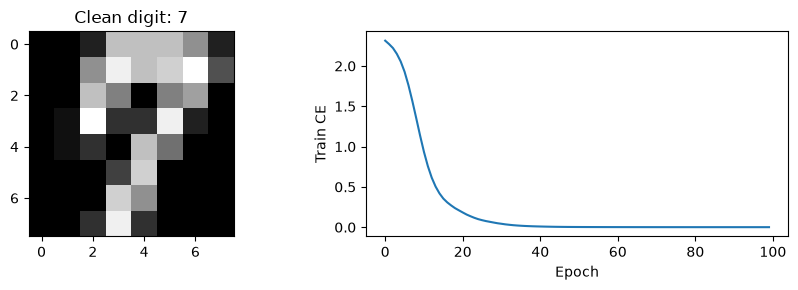

In [8]:
digits = load_digits()
X = (digits.data / 16.0).astype(np.float32)
y = digits.target
ids = np.arange(len(y))
rest, test_ids = train_test_split(ids, test_size=500, random_state=42, stratify=y)
rest, pool_ids = train_test_split(rest, test_size=500, random_state=43, stratify=y[rest])
train_ids, val_ids = train_test_split(rest, train_size=600, random_state=44, stratify=y[rest])
groups = [train_ids, val_ids, pool_ids, test_ids]
assert len(set(np.concatenate(groups))) == len(X)
for i in range(4):
    for j in range(i):
        assert not set(groups[i]) & set(groups[j])
Xtr, ytr = X[train_ids], y[train_ids]
Xval, yval = X[val_ids], y[val_ids]
Xpool = X[pool_ids]
Xte, yte = X[test_ids], y[test_ids]
clean, clean_hist = fit(Xtr, ytr)
baseline_acc = acc(clean, Xte, yte)
results["baseline"] = {"train_accuracy": acc(clean, Xtr, ytr),
                       "validation_accuracy": acc(clean, Xval, yval),
                       "test_accuracy": baseline_acc}
display(pd.DataFrame([results["baseline"]]))
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].imshow(Xtr[0].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
ax[0].set_title(f"Clean digit: {ytr[0]}")
ax[1].plot(clean_hist); ax[1].set(xlabel="Epoch", ylabel="Train CE")
plt.tight_layout(); plt.show()

### Задание A1. Label flipping 

Реализуйте изменение ровно `floor(rate * n)` меток без изменения входов и без изменения исходного массива.
Новая метка должна отличаться от старой. Сравните доли 0, 0.1, 0.3 при одинаковой инициализации модели.
Это простой baseline отравления, а не оптимизированная атака.

In [9]:
def flip_labels(y, rate, k, seed=42):
    y_new = np.array(y, copy=True)

    n = len(y_new)
    n_changed = int(np.floor(rate * n))

    rng = np.random.default_rng(seed)

    changed = rng.choice(
        n,
        size=n_changed,
        replace=False
    )

    # Ненулевой сдвиг по модулю k гарантирует другую метку
    shifts = rng.integers(1, k, size=n_changed)
    y_new[changed] = (y_new[changed] + shifts) % k

    return y_new, changed

,poison_rate,n_changed,clean_test_accuracy
0,0.0,0,0.958
1,0.1,60,0.866
2,0.3,180,0.688


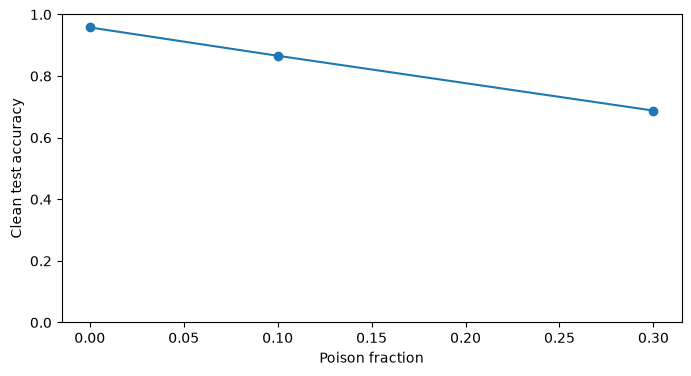

In [10]:
flip_probe = flip_labels(ytr, 0.1, 10)
if flip_probe is None:
    pending("A1")
else:
    yf, changed = flip_probe
    assert len(changed) == 60 and np.sum(yf != ytr) == 60
    assert np.array_equal(ytr, y[train_ids])
    assert not np.shares_memory(yf, ytr)
    flip_rows = []
    for rate in [0, 0.1, 0.3]:
        yf, changed = flip_labels(ytr, rate, 10)
        m = clean if rate == 0 else fit(Xtr, yf)[0]
        flip_rows.append({"poison_rate": rate, "n_changed": len(changed),
                         "clean_test_accuracy": acc(m, Xte, yte)})
    results["label_flipping"] = flip_rows
    display(pd.DataFrame(flip_rows))
    plt.plot([r["poison_rate"] for r in flip_rows],
             [r["clean_test_accuracy"] for r in flip_rows], "o-")
    plt.xlabel("Poison fraction"); plt.ylabel("Clean test accuracy")
    plt.ylim(0, 1); plt.show()

## B. Backdoor: локальный dirty-label опыт

Атакующий заменяет часть train на изображения с патчем 2×2 в правом нижнем углу и меткой `target=0`.
При инференсе тот же патч должен направлять нетаргетные цифры в класс 0.
Это учебная реализация идеи [BadNets](https://arxiv.org/abs/1708.06733), не точное воспроизведение статьи.
Доля отравления определяется от ВСЕХ 600 train, а выбираются только записи с исходной меткой, отличной от 0.

$
ASR=\frac{\sum_{i:y_i\ne t}1[\arg\max f(T(x_i))=t]}{|\{i:y_i\ne t\}|}.
$

Проверяем четыре условия: clean model / poisoned model × clean input / triggered input.
ASR clean-модели на том же триггере показывает, не объясняется ли эффект одним повреждением входа.
Дополнительно считаем условный ASR на тех нетаргетных объектах, которые эта же модель правильно распознавала без патча.

### Задание B1. Триггер и отравление

`trigger` должен копировать вход, сохранять форму `(n,64)` и менять только последние 2×2 пикселя.
`poison_data` заменяет, а не добавляет записи; возвращает индексы изменений.
Для воспроизводимого сравнения выбор индексов должен зависеть только от `seed`.

In [11]:
TARGET = 0

def trigger(x):
    # Не изменяем исходный массив
    z = np.array(x, copy=True)

    # Переходим от (n, 64) к (n, 8, 8)
    z = z.reshape(-1, 8, 8)

    # Патч 2x2 в правом нижнем углу
    z[:, -2:, -2:] = 1.0

    # Возвращаем исходную форму (n, 64)
    return z.reshape(-1, 64)


def poison_data(x, y, rate=0.15, target=TARGET, seed=42):
    # Копии, чтобы исходные x/y не изменились
    xp = np.array(x, copy=True)
    yp = np.array(y, copy=True)

    n = len(y)

    # Доля считается от ВСЕХ train-записей
    n_poison = int(np.floor(rate * n))

    # Кандидаты: только нетаргетные классы
    candidates = np.flatnonzero(y != target)

    # Воспроизводимый выбор
    rng = np.random.default_rng(seed)

    # Выбираем ровно n_poison записей
    ix = rng.choice(
        candidates,
        size=n_poison,
        replace=False
    )

    # Добавляем trigger только выбранным объектам
    xp[ix] = trigger(xp[ix])

    # Меняем их истинную метку на target
    yp[ix] = target

    return xp, yp, ix

### Задание B2. Корректный знаменатель 

Реализуйте ASR по уже вычисленным предсказаниям; возвращайте NaN, если допустимых объектов нет.
Не включайте истинный target-класс. Вызов не должен изменять массивы.

In [12]:
def targeted_asr(pred, y, target):
    # Учитываем только объекты, которые НЕ относятся к target
    mask = (y != target)

    # Если допустимых объектов нет
    if mask.sum() == 0:
        return np.nan

    # Доля нетаргетных объектов,
    # которые модель отправила в target
    return float((pred[mask] == target).mean())

,model,clean_accuracy,ASR,ASR_n,conditional_ASR,conditional_n,triggered_accuracy
0,clean,0.958,0.0,450,0.0,431,0.698
1,poisoned,0.958,1.0,450,1.0,430,0.100


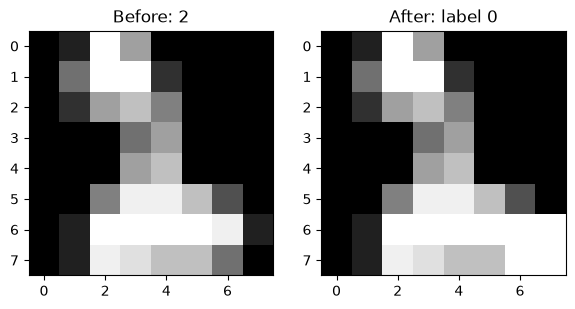

In [ ]:
poisoned = None
probe = poison_data(Xtr, ytr)
asr_probe = targeted_asr(np.array([0, 0, 1]), np.array([0, 2, 3]), 0)
if probe is None or asr_probe is None or trigger(Xtr[:1]) is None:
    pending("B1/B2")
else:
    assert asr_probe == 0.5
    assert np.isnan(targeted_asr(np.array([0]), np.array([0]), 0))
    xp, yp, ix = probe
    assert len(ix) == 90 and np.all(yp[ix] == TARGET) and np.all(ytr[ix] != TARGET)
    keep = np.setdiff1d(np.arange(len(ytr)), ix)
    assert np.array_equal(xp[keep], Xtr[keep])
    assert np.array_equal(Xtr, X[train_ids]) and np.array_equal(ytr, y[train_ids])
    assert not np.shares_memory(xp, Xtr)
    assert np.all(trigger(Xtr[:2]).reshape(-1, 8, 8)[:, -2:, -2:] == 1)
    mask_pixels = np.ones((8, 8), bool); mask_pixels[-2:, -2:] = False
    assert np.array_equal(trigger(Xtr[:2]).reshape(-1,8,8)[:,mask_pixels],
                          Xtr[:2].reshape(-1,8,8)[:,mask_pixels])
    poisoned, _ = fit(xp, yp)
    bd_rows = []
    for name, model in [("clean", clean), ("poisoned", poisoned)]:
        pc = probs(model, Xte).argmax(1)
        pt = probs(model, trigger(Xte)).argmax(1)
        eligible = (yte != TARGET) & (pc == yte)
        bd_rows.append({"model": name, "clean_accuracy": accuracy_score(yte, pc),
                        "ASR": targeted_asr(pt, yte, TARGET),
                        "ASR_n": int((yte != TARGET).sum()),
                        "conditional_ASR": float((pt[eligible] == TARGET).mean()),
                        "conditional_n": int(eligible.sum()),
                        "triggered_accuracy": accuracy_score(yte, pt)})
    results["backdoor"] = bd_rows
    display(pd.DataFrame(bd_rows))
    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    ax[0].imshow(Xtr[ix[0]].reshape(8,8), cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(f"Before: {ytr[ix[0]]}")
    ax[1].imshow(xp[ix[0]].reshape(8,8), cmap="gray", vmin=0, vmax=1)
    ax[1].set_title(f"After: label {yp[ix[0]]}")
    plt.tight_layout(); plt.show()

### Контроль защиты с известным триггером

Ниже защитник УЖЕ знает положение патча. Он зануляет эту область на ВСЕХ входах.
Это oracle-sanitization: полезный контроль причинности, но не детектор неизвестных backdoor.
Считаем и ASR, и потерю clean accuracy. Дополнительный опыт: fine-tuning на чистой validation;
после него эта выборка становится обучающей и больше не годится для независимой оценки.
Ни один из этих опытов не даёт универсальной гарантии ([NIST](https://nvlpubs.nist.gov/nistpubs/ai/NIST.AI.100-2e2025.pdf)).

,defense,clean_accuracy,ASR
0,No defense,0.958,1.000000
1,Known patch erase,0.956,0.002222
2,Clean fine-tuning,0.960,0.997778


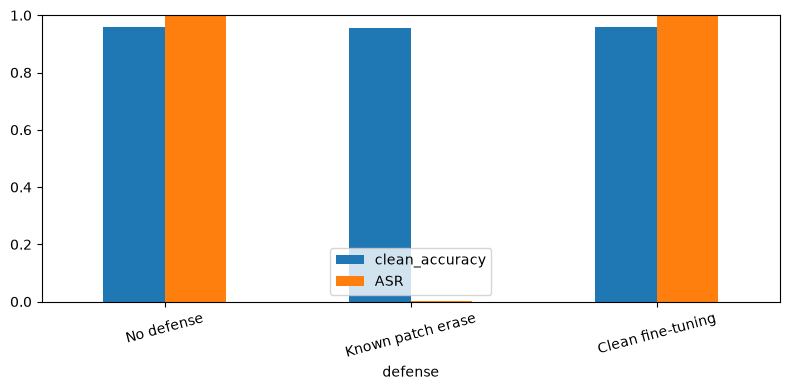

In [14]:
def erase_known_patch(x):
    z = x.copy().reshape(-1,8,8)
    z[:, -2:, -2:] = 0
    return z.reshape(-1,64)

if poisoned is not None:
    ft = copy.deepcopy(poisoned)
    opt = torch.optim.Adam(ft.parameters(), lr=0.001)
    for _ in range(40):
        opt.zero_grad()
        loss = F.cross_entropy(ft(tensor(Xval)), torch.as_tensor(yval, dtype=torch.long))
        loss.backward(); opt.step()
    defense_rows = []
    for name, model, transform in [
        ("No defense", poisoned, lambda x: x),
        ("Known patch erase", poisoned, erase_known_patch),
        ("Clean fine-tuning", ft.eval(), lambda x: x)]:
        defense_rows.append({"defense": name, "clean_accuracy": acc(model, transform(Xte), yte),
                            "ASR": targeted_asr(probs(model, transform(trigger(Xte))).argmax(1), yte, TARGET)})
    results["backdoor_defense"] = defense_rows
    display(pd.DataFrame(defense_rows))
    pd.DataFrame(defense_rows).set_index("defense").plot.bar(rot=15, ylim=(0,1))
    plt.tight_layout(); plt.show()
else:
    pending("Backdoor defense")

## C. Membership inference: отдельный синтетический стенд

Определяем, входила ли запись `(x,y)` в train целевой модели.
Loss-score требует истинной метки и вектора вероятностей: это явно заданные возможности атакующего.
Используем отрицательную cross-entropy, то есть `log p(y|x)`; больший score означает «вероятнее member».
Идея shadow calibration связана с [Shokri et al.](https://arxiv.org/abs/1610.05820).

1600 синтетических записей делятся на 4 непересекающихся набора по 400:
target members, target nonmembers, shadow members, shadow nonmembers.
Shadow-данные и алгоритм обучения доступны атакующему. Порог выбирается ТОЛЬКО на shadow;
истинные membership-метки target открываются лишь оценщику после атаки.
Один shadow не является реализацией LiRA. Цель: честно показать принцип калибровки.

### Задание C1. Loss-score и порог 

Напишите `membership_score` через логарифм вероятности истинного класса с защитой от log(0).
В `choose_threshold` максимизируйте balanced accuracy на calibration, перебрав уникальные score
и дополнительный порог выше максимума. Используйте соглашение `score >= threshold`.

In [15]:
def membership_score(p, labels):
    p = np.asarray(p)
    labels = np.asarray(labels)

    # Берём вероятность истинного класса
    true_p = p[np.arange(len(labels)), labels]

    # Защита от log(0)
    true_p = np.clip(true_p, 1e-12, 1.0)

    # Чем выше вероятность истинного класса,
    # тем выше score и тем вероятнее member
    return np.log(true_p)

def choose_threshold(scores, member):
    scores = np.asarray(scores)
    member = np.asarray(member).astype(int)

    # Кандидаты: все уникальные значения score
    thresholds = np.unique(scores)

    best_threshold = thresholds[0]
    best_bacc = -np.inf

    for threshold in thresholds:
        guessed = scores >= threshold

        bacc = balanced_accuracy_score(
            member,
            guessed
        )

        if bacc > best_bacc:
            best_bacc = bacc
            best_threshold = threshold

    return float(best_threshold)

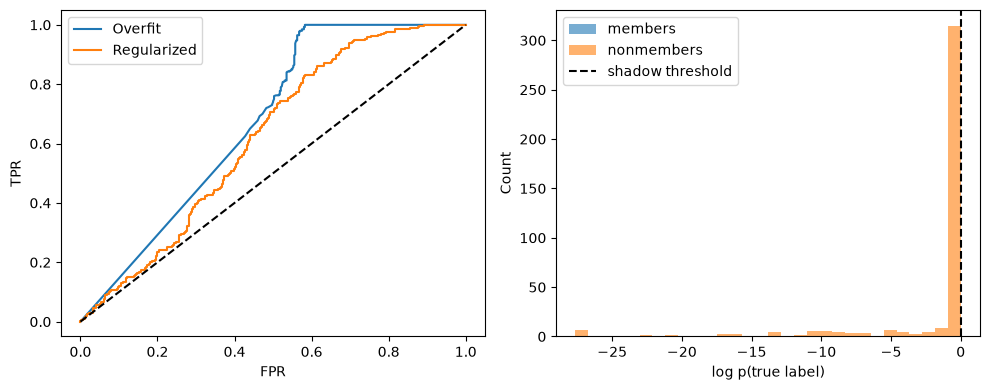

,setting,train_accuracy,nonmember_accuracy,gap,threshold_shadow,ROC_AUC,balanced_accuracy,TPR,FPR,advantage,TPR_at_empirical_FPR_le_1pct
0,Overfit,1.0000,0.7825,0.2175,-0.000037,0.671634,0.7075,1.0000,0.5850,0.415,0.00
1,Regularized,0.9825,0.8175,0.1650,-0.337001,0.618337,0.6200,0.9375,0.6975,0.240,0.01


Минимальный ненулевой шаг FPR = 0.0025 ; 1% соответствует всего 4 FP, оценка нестабильна.


In [16]:
mia_probe = membership_score(np.array([[.9,.1],[.2,.8]]), np.array([0,1]))
if mia_probe is None or choose_threshold(np.array([-2., -1.]), np.array([0,1])) is None:
    pending("C1")
else:
    np.testing.assert_allclose(mia_probe, np.log([.9,.8]))
    threshold_probe = choose_threshold(np.array([-3.,-2.,-1.,-.1]), np.array([0,0,1,1]))
    assert balanced_accuracy_score([0,0,1,1], np.array([-3.,-2.,-1.,-.1]) >= threshold_probe) == 1
    XM, yM = make_classification(n_samples=1600, n_features=40, n_informative=12,
                                 n_redundant=8, class_sep=0.7, flip_y=0.08, random_state=51)
    mi = np.arange(1600)
    a, b = train_test_split(mi, test_size=800, random_state=52, stratify=yM)
    tm, tn = train_test_split(a, test_size=400, random_state=53, stratify=yM[a])
    sm, sn = train_test_split(b, test_size=400, random_state=54, stratify=yM[b])
    assert len(set(np.r_[tm,tn,sm,sn])) == 1600
    # Фиксированное масштабирование, а не fit scaler по test.
    XM = (XM / 5.0).astype(np.float32)
    member = np.r_[np.ones(400, int), np.zeros(400, int)]
    evaluation_ids, calibration_ids = np.r_[tm,tn], np.r_[sm,sn]
    mia_rows = []
    fig, axes = plt.subplots(1,2, figsize=(10,4))
    for name, epochs, wd in [("Overfit", 400, 0.0), ("Regularized", 60, 0.02)]:
        victim, _ = fit(XM[tm], yM[tm], k=2, epochs=epochs, wd=wd, width=96, seed=61)
        shadow, _ = fit(XM[sm], yM[sm], k=2, epochs=epochs, wd=wd, width=96, seed=62)
        cal_s = membership_score(probs(shadow, XM[calibration_ids]), yM[calibration_ids])
        threshold = choose_threshold(cal_s, member)
        s = membership_score(probs(victim, XM[evaluation_ids]), yM[evaluation_ids])
        guessed = s >= threshold
        tpr = float(guessed[:400].mean()); fpr = float(guessed[400:].mean())
        roc_fpr, roc_tpr, _ = roc_curve(member, s)
        low = float(roc_tpr[roc_fpr <= .01].max())
        train_acc, test_acc = acc(victim, XM[tm], yM[tm]), acc(victim, XM[tn], yM[tn])
        mia_rows.append({"setting": name, "train_accuracy": train_acc, "nonmember_accuracy": test_acc,
                         "gap": train_acc-test_acc, "threshold_shadow": threshold,
                         "ROC_AUC": roc_auc_score(member,s),
                         "balanced_accuracy": balanced_accuracy_score(member,guessed),
                         "TPR": tpr, "FPR": fpr, "advantage": tpr-fpr,
                         "TPR_at_empirical_FPR_le_1pct": low})
        axes[0].plot(roc_fpr, roc_tpr, label=name)
        if name == "Overfit":
            axes[1].hist(s[:400], bins=30, alpha=.6, label="members")
            axes[1].hist(s[400:], bins=30, alpha=.6, label="nonmembers")
            axes[1].axvline(threshold, color="black", linestyle="--", label="shadow threshold")
    axes[0].plot([0,1],[0,1],"k--")
    axes[0].set(xlabel="FPR", ylabel="TPR"); axes[0].legend()
    axes[1].set(xlabel="log p(true label)", ylabel="Count"); axes[1].legend()
    plt.tight_layout(); plt.show()
    results["membership"] = mia_rows
    display(pd.DataFrame(mia_rows))
    print("Минимальный ненулевой шаг FPR =", 1/400,
          "; 1% соответствует всего 4 FP, оценка нестабильна.")

### Интерпретация C

ROC-AUC оценивает ранжирование, а balanced accuracy, TPR и FPR выше относятся к порогу,
заранее выбранному на shadow. `TPR_at_empirical_FPR_le_1pct` является описательной точкой
ROC по итоговому test, НЕ рабочим порогом, который разрешено подобрать по test.
Не выдавайте эту оценку за гарантию при FPR 0.1%: 400 nonmembers недостаточно для надёжного анализа хвоста.
Важность low-FPR оценки обсуждается в [Carlini et al.](https://arxiv.org/abs/2112.03570).

При доле участников $\pi$ среди проверяемых записей:
$
PPV=\frac{TPR\pi}{TPR\pi+FPR(1-\pi)}.
$

При TPR=0.6, FPR=0.1 и $\pi=0.01$ точность положительного заключения составляет около 5.7%.
Сбалансированный стенд сам по себе этого не показывает.
Снижение риска при регуляризации является эмпирическим результатом, не differential privacy.

In [17]:
pi, tpr_example, fpr_example = .01, .6, .1
ppv = tpr_example*pi / (tpr_example*pi + fpr_example*(1-pi))
assert np.isclose(ppv, .05714285714285714)
print(f"Пример PPV = {ppv:.2%}")

Пример PPV = 5.71%


## D. Model inversion: оптимизация входа

Доступ white-box: атакующий знает веса и получает градиент по входу, но НЕ использует train в оптимизации.
Синтезируем изображение класса $c$, минимизируя
$
L(x)=-\log p_\theta(c\mid x)+0.02\|x\|_2^2/d+0.05\,TV(x),\quad x\in[0,1]^{64}.
$

Здесь TV равна сумме средних абсолютных разностей по двум направлениям.
Это демонстрация class-prototype inversion. Она НЕ доказывает извлечение конкретной обучающей записи;
близость к train оценивается отдельно только преподавателем-аудитором.
Связь confidence и inversion изучается в [Fredrikson et al.](https://www.cs.cmu.edu/~mfredrik/papers/fjr2015ccs.pdf).

### Задание D1. Функция потерь и градиент по входу 
Верните скалярную функцию потерь для батча восстанавливаемых изображений.
Нельзя использовать `.detach()` или NumPy внутри loss: градиент должен доходить до `x`.
Оптимизатор ниже меняет только `x`, веса модели фиксированы.

In [18]:
def inversion_loss(model, x, classes):
    # 1. Предсказания модели
    logits = model(x)

    # 2. Cross-entropy: хотим, чтобы модель уверенно
    #    предсказывала указанный класс
    ce = F.cross_entropy(logits, classes)

    # 3. Средний L2-регуляризатор
    #    d = 64 для каждой картинки
    d = x.shape[1]
    l2 = (x ** 2).sum(dim=1).mean() / d

    # 4. Total Variation по горизонтали и вертикали
    img = x.reshape(-1, 8, 8)

    tv_h = torch.abs(img[:, :, 1:] - img[:, :, :-1]).mean()
    tv_v = torch.abs(img[:, 1:, :] - img[:, :-1, :]).mean()

    tv = tv_h + tv_v

    # 5. Общая функция потерь
    loss = ce + 0.02 * l2 + 0.05 * tv

    return loss

,class,restart,confidence,nearest_train_MSE,nearest_test_MSE,nref_each
0,0,0,0.999794,0.137201,0.135504,50
1,0,1,1.000000,0.149314,0.153968,50
2,3,0,1.000000,0.149597,0.143125,51
3,3,1,1.000000,0.148036,0.138062,51
4,8,0,0.999934,0.173786,0.175979,48
5,8,1,0.999805,0.178409,0.181433,48


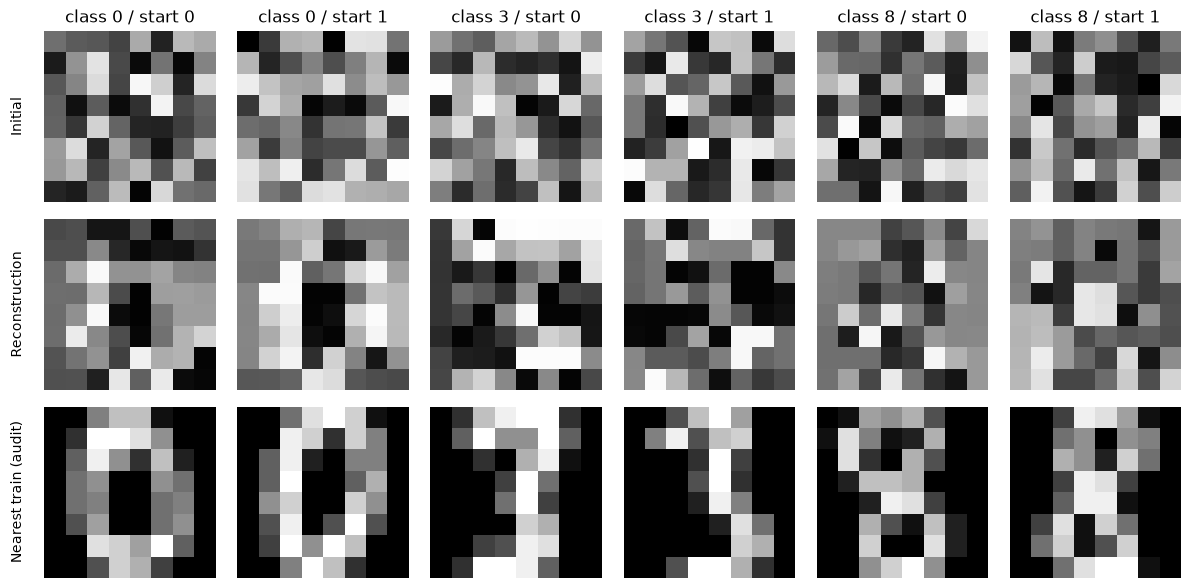

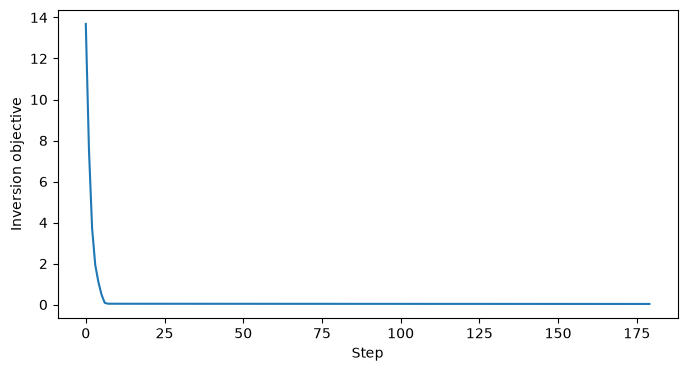

In [19]:
inverse_probe_x = torch.full((2,64), .5, requires_grad=True)
inverse_probe = inversion_loss(clean, inverse_probe_x, torch.tensor([0,1]))
if inverse_probe is None:
    pending("D1")
else:
    assert inverse_probe.ndim == 0
    grad = torch.autograd.grad(inverse_probe, inverse_probe_x)[0]
    assert torch.isfinite(grad).all() and grad.abs().sum() > 0
    before_weights = [p.detach().clone() for p in clean.parameters()]
    for p in clean.parameters():
        p.requires_grad_(False)
    # Два старта для каждого из трёх классов.
    classes = torch.tensor([0,0,3,3,8,8], dtype=torch.long)
    torch.manual_seed(70)
    inv_x = torch.rand((6,64), requires_grad=True)
    initial = inv_x.detach().numpy().copy()
    opt_x = torch.optim.Adam([inv_x], lr=.04)
    inv_hist = []
    for _ in range(180):
        opt_x.zero_grad()
        loss = inversion_loss(clean, inv_x, classes)
        loss.backward(); opt_x.step()
        with torch.no_grad():
            inv_x.clamp_(0,1)
        inv_hist.append(loss.item())
    recon = inv_x.detach().numpy()
    assert all(torch.equal(p, old) for p,old in zip(clean.parameters(), before_weights))
    for p in clean.parameters():
        p.requires_grad_(True)
    # Аудиторский доступ: ближайшие train и held-out не входят в атакующую оптимизацию.
    rows, nearest_train = [], []
    for i, cls in enumerate(classes.numpy()):
        tri = np.flatnonzero(ytr == cls); tei = np.flatnonzero(yte == cls)
        # Одинаковое число кандидатов, чтобы размер множества не смещал nearest-neighbor baseline.
        nref = min(len(tri), len(tei)); tri, tei = tri[:nref], tei[:nref]
        dtr = ((Xtr[tri]-recon[i])**2).mean(1)
        dte = ((Xte[tei]-recon[i])**2).mean(1)
        nearest_train.append(Xtr[tri[dtr.argmin()]])
        rows.append({"class": int(cls), "restart": i%2,
                     "confidence": float(probs(clean,recon[i:i+1])[0,cls]),
                     "nearest_train_MSE": float(dtr.min()),
                     "nearest_test_MSE": float(dte.min()), "nref_each": nref})
    results["inversion"] = rows
    display(pd.DataFrame(rows))
    fig, ax = plt.subplots(3,6, figsize=(12,6))
    for i in range(6):
        for r, arr in enumerate([initial, recon, np.array(nearest_train)]):
            ax[r,i].imshow(arr[i].reshape(8,8), cmap="gray", vmin=0, vmax=1)
            ax[r,i].axis("off")
        ax[0,i].set_title(f"class {classes[i].item()} / start {i%2}")
    for r,label in enumerate(["Initial", "Reconstruction", "Nearest train (audit)"]):
        ax[r,0].text(-.2,.5,label, transform=ax[r,0].transAxes, rotation=90, va="center")
    plt.tight_layout(); plt.show()
    plt.plot(inv_hist); plt.xlabel("Step"); plt.ylabel("Inversion objective"); plt.show()

## E. Model extraction: локальный API с бюджетом

Цель: скопировать предсказания, а не восстановить точные веса.
Атакующий видит только свои query-входы и ответ API; метки `ytr`, `yte`, `y[pool_ids]` не используются в fit клона.
Ниже сравниваются soft probabilities и hard labels при равных бюджетах уникальных примеров.
Идея prediction-API extraction: [Tramèr et al.](https://arxiv.org/abs/1609.02943).
API является программной границей эксперимента, не защищённым процессом: владелец блокнота технически видит все переменные.

Чтобы не платить за одни и те же запросы повторно, один раз получаем 500 ответов и кэшируем их.
Модели с бюджетом 50/150/500 получают только соответствующий префикс ответов.
В эксплуатации метрики аудита потребовали бы отдельного доступа оценщика;
здесь он считает fidelity на test напрямую и не расходует бюджет атакующего.

### Задание E1. Дистилляция

Реализуйте soft cross-entropy по logits student и распределению teacher.
Не передавайте вероятности как logits в `cross_entropy`.
Для hard-label варианта используется стандартная cross-entropy с argmax teacher.

In [23]:
def distill_loss(logits, teacher_p):
    student_log_p = F.log_softmax(logits, dim=1)
    loss_per_sample = -(teacher_p * student_log_p).sum(dim=1)
    return loss_per_sample.mean()

,queries_available,output,fidelity,clone_accuracy,victim_accuracy
0,50,soft,0.784,0.770,0.958
1,50,hard,0.738,0.730,0.958
2,150,soft,0.922,0.904,0.958
3,150,hard,0.894,0.884,0.958
4,500,soft,0.968,0.942,0.958
5,500,hard,0.950,0.940,0.958


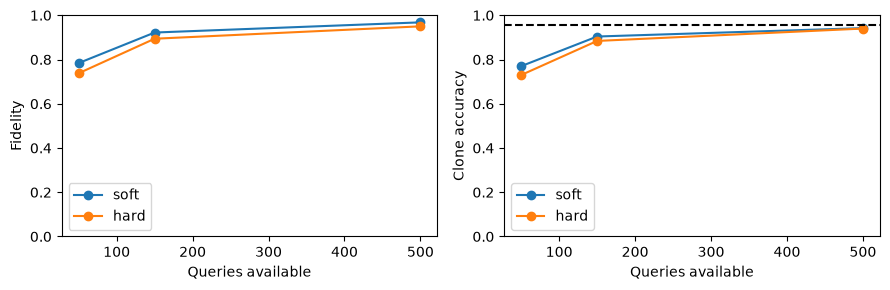

Всего запросов к API в этом опыте: 500


In [24]:
class LocalAPI:
    def __init__(self, model, budget=500):
        self.__model = model
        self.budget, self.used = budget, 0
    def query(self, x):
        if self.used + len(x) > self.budget:
            raise RuntimeError("Query budget exceeded")
        self.used += len(x)
        return probs(self.__model, x)

dl_probe = distill_loss(torch.zeros(2,10, requires_grad=True), torch.full((2,10), .1))
if dl_probe is None:
    pending("E1")
else:
    assert torch.isclose(dl_probe.detach(), torch.tensor(np.log(10), dtype=torch.float32))
    api = LocalAPI(clean, budget=500)
    order = np.random.default_rng(80).permutation(len(Xpool))
    queries = Xpool[order]
    cached_answers = api.query(queries)
    assert api.used == 500
    try:
        api.query(queries[:1])
        raise AssertionError("Budget is not enforced")
    except RuntimeError:
        pass
    victim_test_labels = probs(clean, Xte).argmax(1)
    extraction_rows = []
    for budget in [50,150,500]:
        for mode in ["soft", "hard"]:
            # Это все обучающие данные, доступные данной модели-клону.
            qx, qp = tensor(queries[:budget]), tensor(cached_answers[:budget])
            student = new_model(64,10,seed=81,width=32)
            optimizer = torch.optim.Adam(student.parameters(), lr=.01, weight_decay=1e-4)
            for _ in range(160):
                optimizer.zero_grad()
                logits = student(qx)
                loss = distill_loss(logits, qp) if mode == "soft" else F.cross_entropy(logits, qp.argmax(1))
                loss.backward(); optimizer.step()
            clone_pred = probs(student.eval(), Xte).argmax(1)
            extraction_rows.append({"queries_available": budget, "output": mode,
                                    "fidelity": accuracy_score(victim_test_labels, clone_pred),
                                    "clone_accuracy": accuracy_score(yte, clone_pred),
                                    "victim_accuracy": baseline_acc})
    results["extraction"] = extraction_rows
    display(pd.DataFrame(extraction_rows))
    fig, ax = plt.subplots(1,2, figsize=(9,3))
    ef = pd.DataFrame(extraction_rows)
    for mode in ["soft","hard"]:
        sub = ef[ef.output == mode]
        ax[0].plot(sub.queries_available, sub.fidelity, "o-", label=mode)
        ax[1].plot(sub.queries_available, sub.clone_accuracy, "o-", label=mode)
    for a in ax:
        a.set(xlabel="Queries available", ylim=(0,1)); a.legend()
    ax[0].set_ylabel("Fidelity"); ax[1].set_ylabel("Clone accuracy")
    ax[1].axhline(baseline_acc, color="black", linestyle="--")
    plt.tight_layout(); plt.show()
    print("Всего запросов к API в этом опыте:", api.used)

## F. Протокол и отчёт

### Задание F1. Анализ и расширение 

В основной части сформулируйте по одному выводу для A–E и один отрицательный/неоднозначный результат.
Для каждого укажите модель угроз, доступ атакующего, контроль, числитель и знаменатель метрики,
а также то, что из результата НЕ следует. 

Выберите один вариант:

- **Backdoor**: сравните доли 0.05, 0.15, 0.25 на трёх seed; оставьте фиксированными патч и target.
- **Membership**: повторите оба режима на трёх seed; сравните AUC и PPV при pi=0.01/0.1/0.5.
- **Inversion**: сравните TV=0 и TV=0.05 на трёх seed; сопоставьте confidence и видимость класса.
- **Extraction**: повторите кривые бюджетов на трёх seed; сравните разброс soft/hard fidelity.

Выбор варианта согласуется до просмотра итогового test. При изменении гиперпараметров используйте
validation или отдельный development-стенд. Не используйте обучающую метку public pool для клона.
Покажите mean ± sample SD; не называйте интервал mean ± SD доверительным.
Не исключайте «неудачные» seed.

### Вопросы 

- **Целостность данных**: чем случайная ошибка разметки отличается от намеренного poisoning?
- **Backdoor**: почему высокая clean accuracy не исключает высокий ASR? Зачем исключать target из знаменателя?
- **MIA**: зачем нужен shadow? Почему порог на target test означает утечку методики оценки?
- **Приватность**: почему AUC=0.5 у одной атаки не доказывает отсутствие утечек?
- **Inversion**: почему высокая confidence и похожая картинка не доказывают кражу конкретной записи?
- **Extraction**: почему модель-клон может иметь высокую fidelity, но низкую accuracy?
- **Защита**: почему weight decay и ограничение API не дают гарантии differential privacy?

### Что сдавать

Сдайте заполненный `.ipynb` с выводами и графиками, таблицу результатов, версии среды,
seed и краткое заключение (до 2 страниц). Все TODO должны быть реализованы.
Если блок пропущен, строка «не выполнено» не является результатом эксперимента.
Отсутствие ошибок при Run All само по себе не означает выполнения лабораторной.

### Выводы по основным частям

**A. Label flipping**

В этой части проверялось, что происходит с моделью, если атакующий меняет часть правильных меток в обучающей выборке. Атакующий имеет доступ к части обучающих данных и может изменять их метки. В качестве контроля использовалась обычная модель без изменения меток.

Основная метрика — accuracy на чистом тесте:

$$
Accuracy=\frac{\text{число правильных предсказаний}}{\text{число всех тестовых объектов}}
$$

Результат показывает, как изменение меток влияет на качество модели. При этом результат не означает, что модель будет вести себя так же на другом датасете или при других способах изменения меток.

---

**B. Backdoor**

Здесь проверялось, можно ли встроить в модель скрытый триггер. Атакующий меняет часть обучающих изображений: добавляет патч 2×2 в правом нижнем углу и меняет их метку на класс 0.

Контроль — чистая модель без отравления.

Главная метрика — ASR:

$$
ASR=\frac{\text{non-target объектов, которые с триггером стали классом 0}}
{\text{всех non-target объектов}}
$$

Также использовался `conditional_ASR`, где в знаменателе только те non-target объекты, которые модель правильно классифицировала без триггера.

По трём запускам poisoned-модель имела средний ASR около **0.9993**, то есть практически все non-target изображения с триггером переводились в класс 0. При этом чистая accuracy почти не изменилась: среднее значение было около **0.9587**.

Это показывает, что backdoor может работать даже тогда, когда обычная accuracy остаётся высокой. При этом результат не означает, что такой backdoor будет работать с любым другим патчем или на другом датасете.

---

**C. Membership inference**

Здесь атакующий пытается определить, использовался ли конкретный объект при обучении модели. У атакующего есть правильная метка объекта и вероятности классов, которые выдала модель.

В качестве score использовалась вероятность правильного класса в логарифмической форме:

$$
score=\log p(y|x)
$$

Контроль — сравнение переобученной и регуляризованной моделей.

TPR показывает долю настоящих участников обучения, которых атака правильно нашла:

$$
TPR=\frac{TP}{TP+FN}
$$

FPR показывает долю объектов, которые не участвовали в обучении, но были ошибочно названы участниками:

$$
FPR=\frac{FP}{FP+TN}
$$

AUC показывает, насколько хорошо score в целом разделяет members и non-members.

В моём эксперименте AUC была выше случайного уровня 0.5, поэтому в score присутствовал некоторый сигнал о membership. При этом это не означает, что по одному такому score можно надёжно доказать, что конкретный человек или объект был в обучающей выборке.

---

**D. Model inversion**

В этой части модель использовалась для получения изображения, которое сильно связано с выбранным классом. Атакующий знает параметры модели и может считать градиент по входу, но не использует исходную обучающую выборку во время оптимизации.

Контроль — разные запуски оптимизации и сравнение полученного изображения с изображениями из train и test.

Для оптимизации использовалась функция с тремя частями: правильный класс, ограничение больших значений пикселей и TV-регуляризация для уменьшения шума.

Полученное изображение является скорее **прототипом класса**, а не обязательно восстановленным обучающим изображением.

Поэтому из результата нельзя сделать вывод, что модель восстановила конкретную запись из train.

---

**E. Model extraction**

Здесь проверялось, насколько хорошо можно скопировать поведение модели через API. Атакующий не знает веса модели и не использует настоящие метки для обучения clone. Он получает только ответы API на свои запросы.

Контроль — разные бюджеты запросов: **50, 150 и 500**, а также soft и hard ответы.

Основная метрика — fidelity:

$$
Fidelity=
\frac{\text{объекты, где clone совпал с victim}}
{\text{все проверяемые тестовые объекты}}
$$

Результат показывает, насколько хорошо clone повторяет поведение исходной модели. При этом высокая fidelity не означает, что clone восстановил настоящие веса или внутреннюю архитектуру исходной модели.

---

## Отрицательный / неоднозначный результат

Одним из неоднозначных результатов является model inversion. Полученное изображение может выглядеть похожим на нужный класс и иметь высокую уверенность модели, но этого недостаточно, чтобы сказать, что была восстановлена конкретная обучающая картинка. То есть уверенность модели показывает связь изображения с классом, но не доказывает извлечение конкретного объекта из train.

---

## Короткий итог работы

В работе были рассмотрены пять атак на ML/NLP-модели. Label flipping показывает влияние неправильных меток на обучение. Backdoor позволяет получить сильное изменение поведения модели при наличии специального триггера. Membership inference использует различия между поведением модели на train и non-member объектах. Model inversion позволяет получать изображения, связанные с выбранным классом. Model extraction показывает, что поведение модели можно частично копировать через API.

В backdoor-эксперименте получилось сохранить высокую обычную accuracy и одновременно получить почти 100% ASR. Три дополнительных запуска нужны для проверки того, что этот результат не является случайностью одного seed.


In [30]:
rates = [0.05, 0.15, 0.25]
seeds = [42, 100, 70]

backdoor_results = []

for rate in rates:
    for seed in seeds:
        xp, yp, poison_ix = poison_data(
            Xtr, ytr,
            rate=rate,
            target=TARGET,
            seed=seed
        )

        poisoned_model, _ = fit(
            xp, yp,
            k=10,
            epochs=140,
            wd=1e-4,
            seed=seed,
            width=64
        )

        clean_p = probs(poisoned_model, Xte)
        clean_pred = clean_p.argmax(1)

        Xte_triggered = trigger(Xte)
        triggered_p = probs(poisoned_model, Xte_triggered)
        triggered_pred = triggered_p.argmax(1)

        mask_non_target = yte != TARGET

        asr = targeted_asr(
            triggered_pred,
            yte,
            TARGET
        )

        correct_clean = (
            clean_pred == yte
        ) & mask_non_target

        if correct_clean.sum() == 0:
            conditional_asr = np.nan
        else:
            conditional_asr = (
                triggered_pred[correct_clean] == TARGET
            ).mean()

        backdoor_results.append({
            "rate": rate,
            "seed": seed,
            "clean_accuracy": accuracy_score(yte, clean_pred),
            "ASR": asr,
            "conditional_ASR": conditional_asr,
            "triggered_accuracy": accuracy_score(yte, triggered_pred),
            "poison_n": len(poison_ix)
        })

backdoor_df = pd.DataFrame(backdoor_results)
backdoor_df


,rate,seed,clean_accuracy,ASR,conditional_ASR,triggered_accuracy,poison_n
0,0.05,42,0.960,0.997778,0.997680,0.102,30
1,0.05,100,0.968,1.000000,1.000000,0.100,30
2,0.05,70,0.970,0.997778,0.997706,0.102,30
3,0.15,42,0.956,1.000000,1.000000,0.100,90
4,0.15,100,0.966,0.991111,0.990783,0.108,90
5,0.15,70,0.958,0.997778,0.997680,0.102,90
6,0.25,42,0.960,1.000000,1.000000,0.100,150
7,0.25,100,0.962,1.000000,1.000000,0.100,150
8,0.25,70,0.952,1.000000,1.000000,0.100,150


In [31]:
summary = (
    backdoor_df
    .groupby("rate")
    .agg(
        clean_accuracy_mean=("clean_accuracy", "mean"),
        clean_accuracy_sd=("clean_accuracy", lambda x: x.std(ddof=1)),

        ASR_mean=("ASR", "mean"),
        ASR_sd=("ASR", lambda x: x.std(ddof=1)),

        conditional_ASR_mean=("conditional_ASR", "mean"),
        conditional_ASR_sd=("conditional_ASR", lambda x: x.std(ddof=1)),

        triggered_accuracy_mean=("triggered_accuracy", "mean"),
        triggered_accuracy_sd=("triggered_accuracy", lambda x: x.std(ddof=1))
    )
    .reset_index()
)

summary

,rate,clean_accuracy_mean,clean_accuracy_sd,ASR_mean,ASR_sd,conditional_ASR_mean,conditional_ASR_sd,triggered_accuracy_mean,triggered_accuracy_sd
0,0.05,0.966,0.005292,0.998519,0.001283,0.998462,0.001332,0.101333,1.154701e-03
1,0.15,0.960,0.005292,0.996296,0.004626,0.996154,0.004794,0.103333,4.163332e-03
2,0.25,0.958,0.005292,1.000000,0.000000,1.000000,0.000000,0.100000,1.699675e-17


In [25]:
required = ["baseline","label_flipping","backdoor","backdoor_defense","membership","inversion","extraction"]
missing = [name for name in required if name not in results]
print("Разделы с результатами:", list(results))
print("Незавершённые разделы:", missing)
print(f"Время исполнения: {time.perf_counter()-START:.1f} с")
# По желанию сохраните результаты в рабочую папку Jupyter:
# from pathlib import Path
# Path("lecture09_results.json").write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8")

Разделы с результатами: ['baseline', 'label_flipping', 'backdoor', 'backdoor_defense', 'membership', 'inversion', 'extraction']
Незавершённые разделы: []
Время исполнения: 7673.0 с
